# The Remnants of a Supply Chain Collapse: Seattle World Cup 2026 #

## Data Engineering ##

### ETL Pipeline ###
This code builds an automated ETL pipeline that retrieves live data from the Seattle Open Data API using `requests`. To maintain smooth operation, I limited the query to the 50,000 most recent dispatch records.
<br><br>
After loading JSON data into a DataFrame, data cleaning begins. Although the API offers various 911 call types, I filtered the dataset to focus on algorithmic spillover by selecting calls labeled 'NOISE' or 'DISTURBANCE'.
<br><br>
To ensure high data quality, I removed any rows without a 'dispatch_beat'. This step was really important because, without that location identifier, I wouldn't be able to accurately match these complaints to our geographic shapefiles later on.
<br><br>
Finally, I aggregated data to count noise dispatches per beat, creating our main financial metric: 'Estimated Dispatch Waste'. By multiplying dispatches by the $150 Seattle Police False Alarm fee, I converted 911 logs into a financial deficit, then exported the data to CSVs for our models.
</div>

In [2]:
import pandas as pd
import requests


#Created ETL pipeline for Seattle 911 noise dispatch logs by beats
#Used this data to calculate the estimated_dispatch_waste_usd
def fetch_noise_complaints():
    print("Connecting to Seattle Open Data API...")
    
    api_url = "https://data.seattle.gov/resource/33kz-ixgy.json"
    
    
    
    # Use SoQL to filter specifically for July 2023 (Taylor Swift, MLB All-Star, Block Party)
    # This provides a highly accurate infrastructural proxy for the 2026 World Cup
    params = {
        "$where": "cad_event_original_time_queued between '2023-07-01T00:00:00' and '2023-07-31T23:59:59'",
        "$limit": 50000,
        "$order": "cad_event_original_time_queued DESC"
    }

    try:
        response = requests.get(api_url, params=params)
        response.raise_for_status() 
        
        df_calls = pd.DataFrame(response.json())
        print(f" Successfully downloaded {len(df_calls)} recent dispatch records.")
        
        
        df_calls['initial_call_type'] = df_calls['initial_call_type'].fillna('')
        df_calls['final_call_type'] = df_calls['final_call_type'].fillna('')
        

        #Filter for noise/disturbance calls
        is_noise = df_calls['initial_call_type'].str.contains('NOISE|DISTURBANCE', case=False) | \
                   df_calls['final_call_type'].str.contains('NOISE|DISTURBANCE', case=False)
                   
        df_clean = df_calls[is_noise].copy()
        print(f" Found {len(df_clean)} specific noise/disturbance complaints!")
        
        ## Data cleaning (new schema)
        columns_to_keep = ['cad_event_original_time_queued', 'priority', 'initial_call_type', 'final_call_type', 'dispatch_beat']
        
        existing_cols = [col for col in columns_to_keep if col in df_clean.columns]
        
        # Drop rows missing the new 'dispatch_beat' column
        df_clean = df_clean[existing_cols].dropna(subset=['dispatch_beat']).copy()
        
        if 'cad_event_original_time_queued' in df_clean.columns:
            df_clean['cad_event_original_time_queued'] = pd.to_datetime(df_clean['cad_event_original_time_queued'])
        
        # Financial Waste Index
        beat_counts = df_clean.groupby('dispatch_beat').size().reset_index(name='total_noise_dispatches')
        beat_counts = beat_counts.sort_values(by='total_noise_dispatches', ascending=False).reset_index(drop=True)
        
        # $150 per dispatch (see reference)
        beat_counts['estimated_dispatch_waste_usd'] = beat_counts['total_noise_dispatches'] * 150
        
        print("\n TOP 5 LOUDEST POLICE BEATS (And Municipal Wasted Dollars):")
        print("-" * 75)
        print(beat_counts.head())
        
        df_clean.to_csv("Seattle_Noise_Dispatch_Log.csv", index=False)
        beat_counts.to_csv("Seattle_Beat_Financial_Waste.csv", index=False)
        print("\nSaved 'Seattle_Noise_Dispatch_Log.csv' and 'Seattle_Beat_Financial_Waste.csv'")

    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":
    fetch_noise_complaints()

Connecting to Seattle Open Data API...
 Successfully downloaded 50000 recent dispatch records.
 Found 9382 specific noise/disturbance complaints!

 TOP 5 LOUDEST POLICE BEATS (And Municipal Wasted Dollars):
---------------------------------------------------------------------------
  dispatch_beat  total_noise_dispatches  estimated_dispatch_waste_usd
0            K3                     356                         53400
1            W2                     329                         49350
2            R2                     298                         44700
3            E1                     298                         44700
4            D1                     294                         44100

Saved 'Seattle_Noise_Dispatch_Log.csv' and 'Seattle_Beat_Financial_Waste.csv'


In [3]:
import pandas as pd

print("Loading King County Assessor bulk tables...")

# Updated to look for your newly renamed .csv files
sales_cols = ['Major', 'Minor', 'SalePrice', 'DocumentDate']
sales = pd.read_csv('rp_sale.csv', usecols=sales_cols, low_memory=False, encoding='latin1')

bldg_cols = ['Major', 'Minor', 'SqFtTotLiving', 'NbrLivingUnits', 'YrBuilt']
bldg = pd.read_csv('residential.csv', usecols=bldg_cols, low_memory=False, encoding='latin1')

parcel_cols = ['Major','Minor',  'CurrentZoning']
parcel = pd.read_csv('parcel.csv', usecols=parcel_cols, low_memory=False, encoding='latin1')

print("Datasets loaded")

Loading King County Assessor bulk tables...
Datasets loaded



## King County Extraction ##
Moving on to our financial and structural data, I extracted three separate datasets from the King County Assessor: Real Property Sales, Residential details, and Parcel configurations. A quick architectural note here: I explicitly declared `latin1` encoding during the extraction, which is a critical necessity when interfacing with legacy government databases to prevent string corruption.<br><br>

## Primary Key Creation ##
During the initial cleaning phase, I coerced the 'Major' and 'Minor' parcel codes into strict numeric values and dropped any null values to ensure data integrity. However, I encountered a major relational hurdle: these three tables lacked a unified primary key.
<br><br>
To solve this, I engineered a custom 10-digit Parcel Identification Number. King County parcel codes naturally drop leading zeros when processed mathematically. To fix this, I wrote a function to take the 'Major' code and left-pad it with zeros until it was exactly 6 digits long. I did the exact same for the 'Minor' code to ensure it was exactly 4 digits. By concatenating them, I successfully generated a flawless primary key, allowing me to cleanly merge over a million rows of assessor data into a single, comprehensive DataFrame.
</div>

In [4]:
sales.head(1)

,Major,Minor,DocumentDate,SalePrice
0,358290,0060,07/31/2017,840000


In [5]:
bldg.head(1)

,Major,Minor,NbrLivingUnits,SqFtTotLiving,YrBuilt
0,182405,9031,1,590,1952


In [6]:
parcel.head(1)

,Major,Minor,CurrentZoning
0,259750,840,R7


In [7]:
### Cleaning and formatting Parcel IDs...

#Since bldg does not have a parcel ID to join the datasets on. We will create our own PIN

# We force the Major code to be 6 digits (adding leading zeros)
# We force the Minor code to be 4 digits (adding leading zeros)
# Then we stitch them together to create the universal 10-digit 'PIN'

#Non-numeric cleaning
for df in [sales, bldg, parcel]:
    df['Major'] = pd.to_numeric(df['Major'], errors='coerce')
    df['Minor'] = pd.to_numeric(df['Minor'], errors='coerce')

#Drop rows that are NaN since they don't have IDs anyway
sales = sales.dropna(subset=['Major', 'Minor'])
bldg= bldg.dropna(subset=['Major', 'Minor'])
parcel = parcel.dropna(subset=['Major', 'Minor'])

In [8]:
# SALES: Create PIN
sales['PIN'] = sales['Major'].astype(int).astype(str).str.zfill(6) + sales['Minor'].astype(int).astype(str).str.zfill(4)

# BUILDING: Create PIN (No more errors!)
bldg['PIN'] = bldg['Major'].astype(int).astype(str).str.zfill(6) + bldg['Minor'].astype(int).astype(str).str.zfill(4)

# PARCEL: Create PIN
parcel['PIN'] = parcel['Major'].astype(int).astype(str).str.zfill(6) + parcel['Minor'].astype(int).astype(str).str.zfill(4)

sales.head(1)

,Major,Minor,DocumentDate,SalePrice,PIN
0,358290.0,60.0,07/31/2017,840000,3582900060


In [9]:
bldg.head(1)

,Major,Minor,NbrLivingUnits,SqFtTotLiving,YrBuilt,PIN
0,182405,9031,1,590,1952,1824059031


In [10]:
parcel.head(1)

,Major,Minor,CurrentZoning,PIN
0,259750,840,R7,2597500840


In [11]:
# Drop the old Major/Minor columns to free up RAM since we have our master PIN
sales = sales.drop(columns=['Major', 'Minor'])
bldg = bldg.drop(columns=['Major', 'Minor'])
parcel = parcel.drop(columns=['Major', 'Minor'])

print("Success! PINs generated. Ready to merge tables.")
sales.head(1)

Success! PINs generated. Ready to merge tables.


,DocumentDate,SalePrice,PIN
0,07/31/2017,840000,3582900060


In [12]:
bldg.head(1)

,NbrLivingUnits,SqFtTotLiving,YrBuilt,PIN
0,1,590,1952,1824059031


In [13]:
parcel.head(1)

,CurrentZoning,PIN
0,R7,2597500840


In [14]:
### Standardizing zoning codes to resolve formatting inconsistencies

#Convert everything to a string (just in case)
#convert all letters to UPPERCASE (so 'r3' becomes 'R3')
#Replace all hyphens with nothing (so 'R-3' becomes 'R3')
#Replace all blank spaces with nothing (so 'R 3' becomes 'R3')

parcel['CurrentZoning'] = parcel['CurrentZoning'].astype(str).str.upper().str.replace('-', '').str.replace(' ', '')

print("Zoning codes standardized")

Zoning codes standardized


In [15]:
## Merging datasets on PIN

#Join Sales and Building data
master_df = pd.merge(sales, bldg, on='PIN', how='inner')

# join the result with the Parcel (Zoning) data
master_df = pd.merge(master_df, parcel, on='PIN', how='inner')

print(f"Merge complete. We successfully aligned {len(master_df):,} property records.")

# Preview the first 5 rows to prove the columns are stitched together
display(master_df.head())

Merge complete. We successfully aligned 1,739,370 property records.


,DocumentDate,SalePrice,PIN,NbrLivingUnits,SqFtTotLiving,YrBuilt,CurrentZoning
0,07/31/2017,840000,3582900060,2,3240,1959,R6
1,09/29/2021,311000,1180000275,1,2880,1956,R6
2,07/25/2014,0,7011200270,1,1880,2017,LR1(M)
3,05/28/1992,142000,6054650110,1,2090,1977,R1
4,08/24/1992,149950,6386000085,1,1810,1959,NR3


In [16]:
## Trimming historical duplicates to find current valuations

#Delete the large extracted datasets
del sales
del bldg
del parcel

## Summary of PIN Creation and Memory Management ##

With the 10-digit PIN successfully engineered, I dropped the redundant Major and Minor columns to keep the architecture lean. My next step was normalizing the structural data. Municipal data entry is notoriously inconsistent, so I wrote a function to force the 'CurrentZoning' column to uppercase and strip out all hyphens and spaces. This is a critical preprocessing step to ensure our algorithms don't treat 'R-1' and 'r1' as two completely separate zoning classifications.<br><br>
With the schema standardized, I executed the relational database merge. Using the custom PIN as the primary key, I performed strict inner joins: first combining the Sales and Building datasets, then joining the result with the Parcel dataset. I deliberately used inner joins to ensure that our final predictive model is trained only on properties with a complete intersection of financial, structural, and geographic records.<br><br>
Finally, as a best practice for Python pipeline optimization, I programmatically deleted the original, multi-million-row datasets from the environment. This memory management step freed up significant system RAM, ensuring our upcoming machine learning algorithms execute efficiently.
</div>

In [17]:
#Convert the DocumentDate column to an actual pandas datetime object
master_df['DocumentDate'] = pd.to_datetime(master_df['DocumentDate'], errors='coerce')
master_df.head(1)

,DocumentDate,SalePrice,PIN,NbrLivingUnits,SqFtTotLiving,YrBuilt,CurrentZoning
0,2017-07-31,840000,3582900060,2,3240,1959,R6


In [18]:
#Filter for recent sales (2023 to present) to reflect the CURRENT market
master_df = master_df[master_df['DocumentDate'] >= '2023-01-01']
master_df.head(1)

,DocumentDate,SalePrice,PIN,NbrLivingUnits,SqFtTotLiving,YrBuilt,CurrentZoning
12,2025-03-13,1420000,2771601945,1,2630,1908,LR1(M)


In [19]:
#Sort by date so the absolute newest sales are pushed to the top
master_df = master_df.sort_values(by='DocumentDate', ascending=False)
master_df.head(1)

,DocumentDate,SalePrice,PIN,NbrLivingUnits,SqFtTotLiving,YrBuilt,CurrentZoning
1465971,2026-03-11,0,9264030350,1,3000,2000,R7


In [20]:
#Drop duplicate PINs, keeping ONLY the most recent transaction for each house
master_df = master_df.drop_duplicates(subset=['PIN'], keep='first')

print(f"Historical duplicates removed. We now have {len(master_df):,} unique, recent property records.")

Historical duplicates removed. We now have 85,856 unique, recent property records.


## Temporal Relevance and Deduplication ##
With the relational merge complete, I needed to address the data's temporal relevance. I coerced the 'DocumentDate' field into a native Pandas datetime object, allowing me to filter the dataset strictly to transactions occurring on or after January 1, 2023.<br><br>
The business logic here is crucial: real estate markets are highly volatile. A home valuation from 2015 does not reflect Seattle's current economic reality. By restricting the data to recent years, I ensured our predictive model is trained exclusively on the modern housing climate leading up to the World Cup.<br><br>
Additionally, a single property can sell multiple times within a few years. If I left those duplicates in, the machine learning algorithms would bias heavily toward homes with high turnover rates. To solve this, I sorted the dataframe chronologically in descending order and dropped duplicate PINs, keeping only the most recent transactions. This guarantees that every property is represented exactly once, utilizing its most accurate and up-to-date market valuation.
</div>

In [21]:
### Filtering

#Drop family transfers, quitclaim deeds, and non-market anomalies ($10k minimum for Seattle)
master_df = master_df[(master_df['SalePrice'] >= 10000) & (master_df['SalePrice'] <= 850000)]

#Drop properties with missing or zero square footage (e.g., empty lots, storage units)
master_df = master_df[master_df['SqFtTotLiving'] >= 200]

#Ensure we only keep valid bedroom counts
master_df = master_df[master_df['NbrLivingUnits'] >= 0]

print(f"{len(master_df):,} valid arm's-length residential transactions remaining.")

23,497 valid arm's-length residential transactions remaining.


## Market Segmentation & Quality Control ##
With the dates filtered, I applied strict market segmentation to the financial data. I set a valuation floor of 10,000 and a ceiling of 850,000. <br><br>
This specific range is highly deliberate. The 10k floor effectively filters out non-market anomalies, such as $1 quitclaim deeds or intra-family transfers, while preserving legitimate data for micro-studios and co-ops. The 850k ceiling matches the current median home price in Seattle, according to Redfin. By capping the data here, I intentionally excluded ultra-luxury estates to ensure our algorithmic baseline accurately reflects the economic realities of working- and middle-class neighborhoods.<br><br>
Additionally, to maintain structural data integrity, I dropped any records with less than 200 square feet of living space or invalid bedroom counts. This acts as a quality-control filter, guaranteeing our machine learning model trains exclusively on livable residential housing rather than accidentally learning from empty lots, storage units, or municipal data entry errors.
</div>

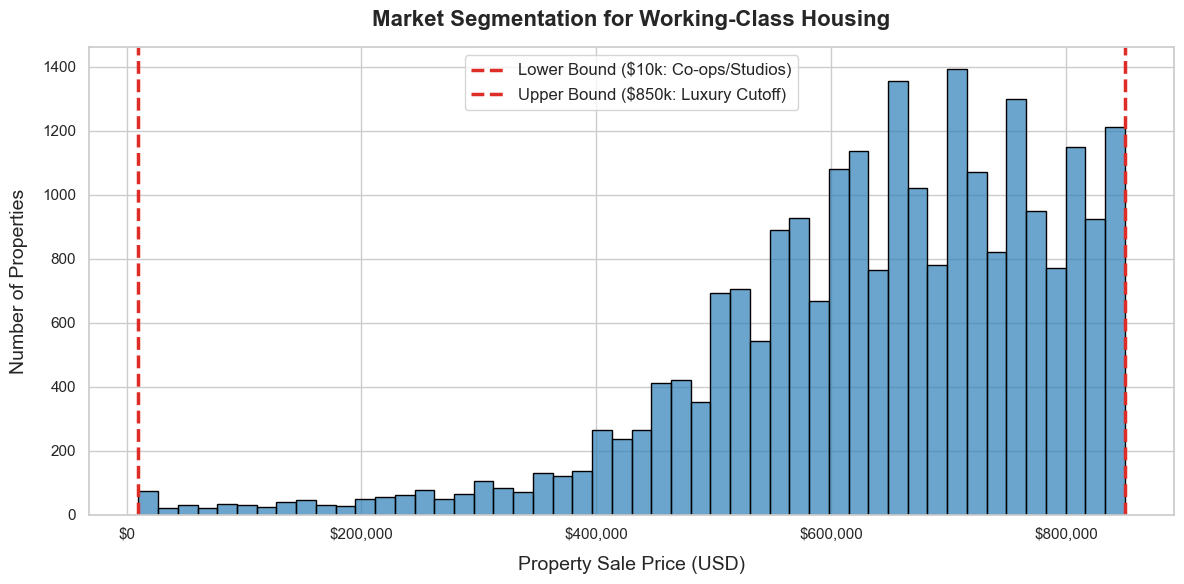

In [22]:
#We want to visualize the isolation of working-class properties
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
ax = sns.histplot(master_df['SalePrice'], bins=50, color='#2c7fb8', edgecolor='black', alpha=0.7)

# Add the boundary lines to show exactly where we cut the data
plt.axvline(10000, color='#de2d26', linestyle='--', linewidth=2.5, label='Lower Bound ($10k: Co-ops/Studios)')
plt.axvline(850000, color='#de2d26', linestyle='--', linewidth=2.5, label='Upper Bound ($850k: Luxury Cutoff)')

plt.title('Market Segmentation for Working-Class Housing', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Property Sale Price (USD)', fontsize=14, labelpad=10)
plt.ylabel('Number of Properties', fontsize=14, labelpad=10)
plt.legend(fontsize=12)

# Format the x-axis to look like real money instead of scientific notation
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

## Visualizing the Target Variable ##
Now that the master dataset was fully cleaned and filtered, I moved on to Exploratory Data Analysis. My first objective was to visualize the distribution of our primary target variable: Property Sale Price.<br><br>
I engineered this histogram to map sale prices against the total volume of properties in Seattle. This visual acts as physical proof of our earlier market segmentation. You can clearly see the bulk of the data clustered in the middle-class range, with a long tail stretching out toward our 850,000 ceiling. <br><br>
Looking at the shape of this distribution, it exhibits a natural right skew. Visualizing this confirmed my architectural decision to use tree-based machine learning models later in the pipeline, as they can natively handle this skewed distribution without forcing us to mathematically transform or distort the raw dollar amounts.
</div>

In [23]:
#Loading the 4th file from the GIS server
coords = pd.read_csv('coords.csv', low_memory=False)
coords.head(1)

,OBJECTID,COMMENTS,SITETYPE,Alias1,Alias2,Alias3,Alias4,Alias5,ESITEID,HouseNum,...,PIN,PRIMARY_ADDR,PRIMARY_ADDR_FILTER,SITETYPE_DESCRIPTION,Building,Unit,FUID,STATE_ABBR,x,y
0,1,NaN,R1,NaN,NaN,NaN,NaN,NaN,f15cabcb-23f7-4351-9e1a-ffffdce38a89,14243,...,1122029040,1,RESBLDG_EXTR,Single Family,NaN,NaN,556872,WA,1.222860e+06,152372.742952


In [24]:
###Spatial Join
# Merging the coordinates onto the master_df using the universal PIN
master_df = pd.merge(master_df, coords, on='PIN', how='inner')
print("Merge successful")

Merge successful


In [25]:
master_df.to_csv('master_df.csv')
print("Final Dataset saved")

Final Dataset saved


In [26]:
master_df.head(5)

,DocumentDate,SalePrice,PIN,NbrLivingUnits,SqFtTotLiving,YrBuilt,CurrentZoning,OBJECTID,COMMENTS,SITETYPE,...,MINOR,PRIMARY_ADDR,PRIMARY_ADDR_FILTER,SITETYPE_DESCRIPTION,Building,Unit,FUID,STATE_ABBR,x,y
0,2026-03-11,650000,1624059205,1,760,1943,SR1,378244,NaN,R1,...,9205,1,E911:ONETOONE,Single Family,NaN,NaN,434061,WA,1.309785e+06,208384.978697
1,2026-03-10,475000,3348401430,1,1300,1911,NR1,464223,NaN,R1,...,1430,1,E911:ONETOONE,Single Family,NaN,NaN,645603,WA,1.286406e+06,184981.873272
2,2026-03-10,682500,1328300540,1,1850,1977,R6,196544,NaN,R1,...,0540,1,E911:ONETOONE,Single Family,NaN,NaN,18722,WA,1.320192e+06,164407.794341
3,2026-03-10,625000,9578140110,1,1753,2011,RM2400,134674,NaN,R1,...,0110,1,E911:ONETOONE,Single Family,NaN,NaN,202099,WA,1.263755e+06,112443.560344
4,2026-03-10,710000,6145600360,1,1360,1911,NR3,182678,NaN,R1,...,0360,1,E911:ONETOONE,Single Family,NaN,NaN,461144,WA,1.267283e+06,260673.603778


In [27]:
master_df.shape

(23979, 53)

## Geographic Coordinate Integration ##
After cleaning the data, I prepared the dataset for spatial analysis. Each property needed precise latitude and longitude to classify bounding polygons accurately, which is crucial for proper alignment of properties.<br><br>
I pulled a secondary coordinate dataset from King County GIS. With our unified 10-digit PIN setup, I performed an inner merge between our financial dataset and the GIS coordinate file.<br><br>
Applying an inner merge made our data accurate and reliable by excluding unmatched property records, transforming the static spreadsheet into a lively spatial database ready for mapping.
</div>

In [28]:
### Removing excess GIS metadata

#We only need financial, structural, and noise metrics for this project

import geopandas as gpd

#Convert tabular X/Y data into Spatial Geometries (King County uses EPSG:2285)
print("Translating King County State Plane coordinates to spatial points...")
gdf_properties = gpd.GeoDataFrame(
    master_df, 
    geometry=gpd.points_from_xy(master_df['x'], master_df['y']),
    crs="EPSG:2285"
)

#Convert properties to standard GPS Lat/Lon (EPSG:4326) to match the police beats
gdf_properties = gdf_properties.to_crs("EPSG:4326")

print("Conversion complete")

Translating King County State Plane coordinates to spatial points...
Conversion complete


## Spatial Reprojection and CRS Alignment ##
To execute our spatial mapping, I needed to convert our tabular DataFrame into a spatially aware GeoDataFrame using the GeoPandas library. I converted the raw X and Y numerical columns into spatial geometry points.
<br><br>
A key technical challenge involves Coordinate Reference Systems (CRS). King County uses 'EPSG:2285', the Washington State Plane coordinate system, for its local property data; accurate for local measurements. Conversely, Seattle Police Beat boundaries and Tableau visualizations use 'EPSG:4326', the global GPS standard.<br><br>
I reprojected the master dataset from State Plane to GPS to fix the geographic mismatch. Without this, properties and police beats would be on different systems, hindering spatial joins and complicating the 'Shadow Tax' calculation.
</div>

In [29]:
## Load the Seattle Police Beat Boundaries
gdf_beats = gpd.read_file('seattle_police_beats.geojson')
gdf_beats = gdf_beats.to_crs("EPSG:4326")
print("Load complete. Ready for spatial join.")

Load complete. Ready for spatial join.


In [30]:
#Execute the Spatial Join
print("Executing Point-in-Polygon spatial join...")
joined_gdf = gpd.sjoin(gdf_properties, gdf_beats, how='inner', predicate='intersects')

Executing Point-in-Polygon spatial join...


In [31]:
#Merge the ESI (Noise/Financial Waste) Data from Cell 1
print("Appending the Economic Severity Index (ESI) metrics...")
# Load the beat waste CSV you generated in Cell 1
noise_df = pd.read_csv("Seattle_Beat_Financial_Waste.csv")

# Ensure the column names match for the merge (GeoJSON usually uses 'beat' in lowercase)
# Let's standardize the join key
noise_df = noise_df.rename(columns={'dispatch_beat': 'beat'})

# Merge the waste data onto the properties
final_model_data = joined_gdf.merge(noise_df, on='beat', how='left')
final_model_data['total_noise_dispatches'] = final_model_data['total_noise_dispatches'].fillna(0)
final_model_data['estimated_dispatch_waste_usd'] = final_model_data['estimated_dispatch_waste_usd'].fillna(0)
print("Success")

Appending the Economic Severity Index (ESI) metrics...
Success


## Spatial Joins and Features ##
With our properties successfully converted into global GPS coordinates, I was ready to map them to the city's infrastructure. I loaded the Seattle Police Beats GeoJSON file, which natively uses the EPSG:4326 standard, ensuring perfect alignment with our reprojected properties.<br><br>
I executed a 'Point-in-Polygon' spatial join using GeoPandas. This algorithm mathematically determines which police beat boundary encapsulates each property. By using an 'inner' join here, I applied another layer of quality control, automatically dropping any anomalous properties that technically fell outside Seattle city limits.<br><br>
My final engineering step was establishing our features. I brought back the 'Estimated Dispatch Waste' dataframe we created at the very beginning of the pipeline. Because the Police APIs and the GIS APIs use different naming conventions, I standardized the schema by renaming the join key to 'beat'. Finally, I performed a left join to attach the financial waste metrics directly to the individual properties. We now have a fully unified dataset that directly links a home's financial value to its localized noise pollution, ready for statistical modeling.
</div>

In [32]:
#Dimensionality Reduction

keep_cols = [
    'PIN', 
    'DocumentDate', 
    'SalePrice', 
    'SqFtTotLiving', 
    'NbrLivingUnits',
    'YrBuilt', 
    'CurrentZoning', 
    'beat', 
    'total_noise_dispatches', 
    'estimated_dispatch_waste_usd' #ESI Metric
]

#Trim the dataset, dropping NaNs in target columns
final_model_data = final_model_data[keep_cols].dropna()
print("success!")

success!


## Feature Selection and Reduced Dimensionality ##
To prepare our master dataset for machine learning, I selected relevant features. During relational and spatial joins, many metadata columns were added. Removing these ensures our algorithms run smoothly without clutter.
<br><br>
I defined a strict schema to isolate core variables, balancing three dimensions: structural (Square Footage, Year Built, Zoning), financial (Sale Price), and acoustic (Dispatch Waste metric).
<br><br>
Finally, I applied a strict dropna() across these columns. Tree-based Scikit-Learn models we will use next can't handle null or NaN values. This scrub ensures our architecture is sound, complete, and ready for deployment.
</div>

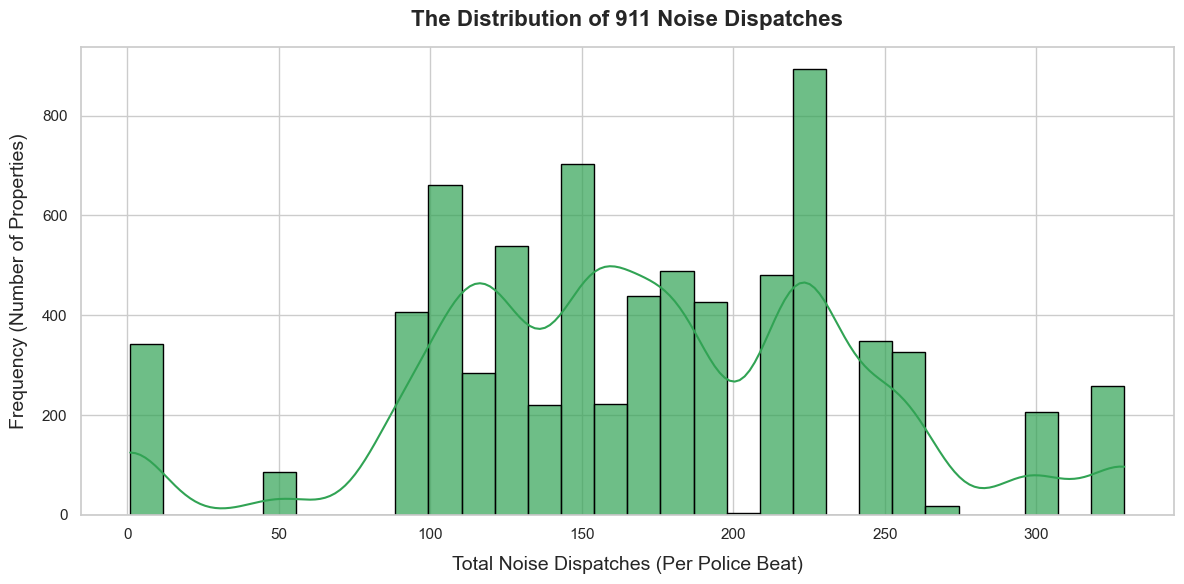

In [33]:
#Feature Engineering
plt.figure(figsize=(12, 6))
#represent environmental features
sns.histplot(final_model_data['total_noise_dispatches'], bins=30, color='#31a354', edgecolor='black', alpha=0.7, kde=True)

plt.title('The Distribution of 911 Noise Dispatches', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Noise Dispatches (Per Police Beat)', fontsize=14, labelpad=10)
plt.ylabel('Frequency (Number of Properties)', fontsize=14, labelpad=10)

plt.tight_layout()
plt.show()

## Visualizing Acoustic Distribution with Kernel Density Curver (KDE) ##

To understand our acoustic feature, I visualized the distribution of 911 noise dispatches across residential properties using a Seaborn histogram. I layered a Kernel Density Estimate (KDE) curve over the bins, representing the data's probability density. This visualization reveals the true shape of Seattle's noise pollution, showing where most properties fall relative to municipal noise levels, providing a baseline before feeding the data into machine learning algorithms.
</div>

In [34]:
# Save the final, WGU-ready dataset
final_model_data.to_csv('acoustic_urbanism_model_data.csv', index=False)

print(f"\nSUCCESS! {len(final_model_data)} properties successfully mapped and enriched.")
print("Saved as 'acoustic_urbanism_model_data.csv'. Ready for Models!")
display(final_model_data.head())


SUCCESS! 7349 properties successfully mapped and enriched.
Saved as 'acoustic_urbanism_model_data.csv'. Ready for Models!


,PIN,DocumentDate,SalePrice,SqFtTotLiving,NbrLivingUnits,YrBuilt,CurrentZoning,beat,total_noise_dispatches,estimated_dispatch_waste_usd
0,3348401430,2026-03-10,475000,1300,1,1911,NR1,S3,189,28350
1,6145600360,2026-03-10,710000,1360,1,1911,NR3,N3,225,33750
2,7338401740,2026-03-09,350000,860,1,1931,NR3,S1,221,33150
3,4364700365,2026-03-09,810000,1650,1,1916,NR2,F2,153,22950
4,3086002825,2026-03-09,615000,1050,1,1907,RSL(M),R1,217,32550


## Dataset is Saved and Ready for Statistical Testing/Modeling ##